# Trade Frequency Optimization — Can We Take More Trades?

The model is very conservative: only 430 trades (0.7% of hours) pass |Q50| > 1x spread.
At 0.5x spread we get 1,586 trades with 66% WR and Sharpe 8.29 — still strong.

**Goal:** Find filters that increase trade count while maintaining accuracy (win rate).

**Approaches:**
1. Fine-grained Q50 threshold sweep (go below 0.5x spread)
2. Q25/Q75 sign agreement as filter (trade when quantiles agree, even if Q50 is small)
3. Confidence ratio: |Q50| / IQR — model sure of direction even if predicted move is small
4. Ensemble voting: how many of Q25/Q50/Q75 agree on direction
5. Per-pair adaptive thresholds
6. Q50 magnitude recalibration — is the model under-predicting move sizes?

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

FEATURES_DIR = Path('../backend/data/features_2')
MODELS_DIR   = Path('../backend/models_5/3_quants')

QUANTILES = [0.25, 0.50, 0.75]
QUANTILE_NAMES = ['Q25', 'Q50', 'Q75']

TRAIN_END = '2024-06-30'
AVG_SPREAD = 0.00028

# Load data
df = pd.read_parquet(FEATURES_DIR / 'all_pairs_microstructure.parquet')
label_cols   = [c for c in df.columns if c.startswith('label_')]
drop_cols    = label_cols + ['pair']
feature_cols = [c for c in df.columns if c not in drop_cols]
TARGET_COL = 'label_1H'

df_test = df[df.index > TRAIN_END].copy()
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# Load models and predict
q_preds = {}
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    q_int = int(q * 100)
    bundle = joblib.load(MODELS_DIR / f'model_1H_Q{q_int}.joblib')
    q_preds[q_name] = bundle['model'].predict(X_test_clean)

# Build results
results = pd.DataFrame({
    'actual_return': y_test_clean.values,
    'Q25': q_preds['Q25'],
    'Q50': q_preds['Q50'],
    'Q75': q_preds['Q75'],
    'pair': df_test.loc[valid_test, 'pair'].values,
}, index=y_test_clean.index)

results['actual_dir'] = np.sign(results['actual_return'])
results['pred_dir'] = np.sign(results['Q50'])
results['abs_Q50'] = np.abs(results['Q50'])
results['iqr'] = results['Q75'] - results['Q25']
results['abs_return'] = np.abs(results['actual_return'])

# Derived signals
results['q25_dir'] = np.sign(results['Q25'])
results['q75_dir'] = np.sign(results['Q75'])
results['q50_dir'] = results['pred_dir']
results['n_agree'] = (results[['q25_dir', 'q50_dir', 'q75_dir']].values == results['q50_dir'].values[:, None]).sum(axis=1)
results['conf_ratio'] = results['abs_Q50'] / results['iqr'].clip(lower=1e-10)

n_days = (results.index.max() - results.index.min()).days
print(f'Test set: {len(results):,} rows, {n_days} days')
print(f'Q50 stats: mean={results["Q50"].mean():.7f}, std={results["Q50"].std():.6f}, median={results["Q50"].median():.7f}')
print(f'IQR stats: mean={results["iqr"].mean():.6f}, std={results["iqr"].std():.6f}')
print(f'Conf ratio stats: mean={results["conf_ratio"].mean():.4f}, median={results["conf_ratio"].median():.4f}')

Test set: 63,637 rows, 548 days
Q50 stats: mean=0.0000034, std=0.000177, median=-0.0000109
IQR stats: mean=0.001129, std=0.000605
Conf ratio stats: mean=0.0445, median=0.0306


## 1. Fine-Grained Q50 Threshold Sweep

Go from 0x to 2x spread in small steps. Where exactly does win rate break down?

In [2]:
def evaluate(mask, direction=None):
    """Evaluate a filter mask. Uses pred_dir by default, or custom direction."""
    if mask.sum() < 10:
        return {'trades': mask.sum(), 'wr': np.nan, 'ev': np.nan, 'total_pnl': np.nan, 'sharpe': np.nan, 'daily_trades': np.nan}
    s = results[mask]
    d = direction if direction is not None else s['pred_dir']
    pnl = d * s['actual_return'] - AVG_SPREAD
    wr = (d == s['actual_dir']).mean()
    ev = pnl.mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    return {
        'trades': mask.sum(),
        'daily_trades': mask.sum() / n_days,
        'wr': wr,
        'ev': ev,
        'total_pnl': pnl.sum(),
        'sharpe': sharpe,
    }

# Sweep from 0x to 2x spread in 0.05x steps
multipliers = np.arange(0, 2.05, 0.05)
sweep = []
for m in multipliers:
    thresh = AVG_SPREAD * m
    mask = results['abs_Q50'] > thresh
    r = evaluate(mask)
    r['threshold'] = m
    sweep.append(r)

sweep_df = pd.DataFrame(sweep)

# Print key rows
print(f'{"Mult":>6} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 70)
for _, row in sweep_df.iterrows():
    if row['threshold'] % 0.25 < 0.01 or row['threshold'] < 0.3:
        flag = ' <<<' if row['ev'] > 0 else ''
        print(f'{row["threshold"]:>5.2f}x {row["trades"]:>8.0f} {row["daily_trades"]:>8.2f} {row["wr"]:>7.1%} {row["ev"]:>12.6f} {row["total_pnl"]:>10.4f} {row["sharpe"]:>8.2f}{flag}')

  Mult   Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
----------------------------------------------------------------------
 0.00x    63637   116.13   51.4%    -0.000209   -13.3202    -5.65
 0.05x    48440    88.39   52.0%    -0.000181    -8.7619    -4.51
 0.10x    34694    63.31   52.7%    -0.000140    -4.8458    -3.10
 0.15x    23197    42.33   53.3%    -0.000090    -2.0799    -1.71
 0.20x    14870    27.14   54.0%    -0.000008    -0.1129    -0.12
 0.25x     9282    16.94   55.7%     0.000127     1.1822     1.58 <<<
 0.50x     1586     2.89   66.1%     0.001266     2.0074     8.29 <<<
 0.75x      703     1.28   73.8%     0.003053     2.1463    13.54 <<<
 1.00x      430     0.78   78.6%     0.004979     2.1408    17.48 <<<
 1.25x      300     0.55   85.0%     0.007244     2.1731    21.58 <<<
 1.50x      243     0.44   88.1%     0.008919     2.1674    24.12 <<<
 1.75x      205     0.37   92.2%     0.010602     2.1735    26.59 <<<
 2.00x      176     0.32   93.8%     0.012

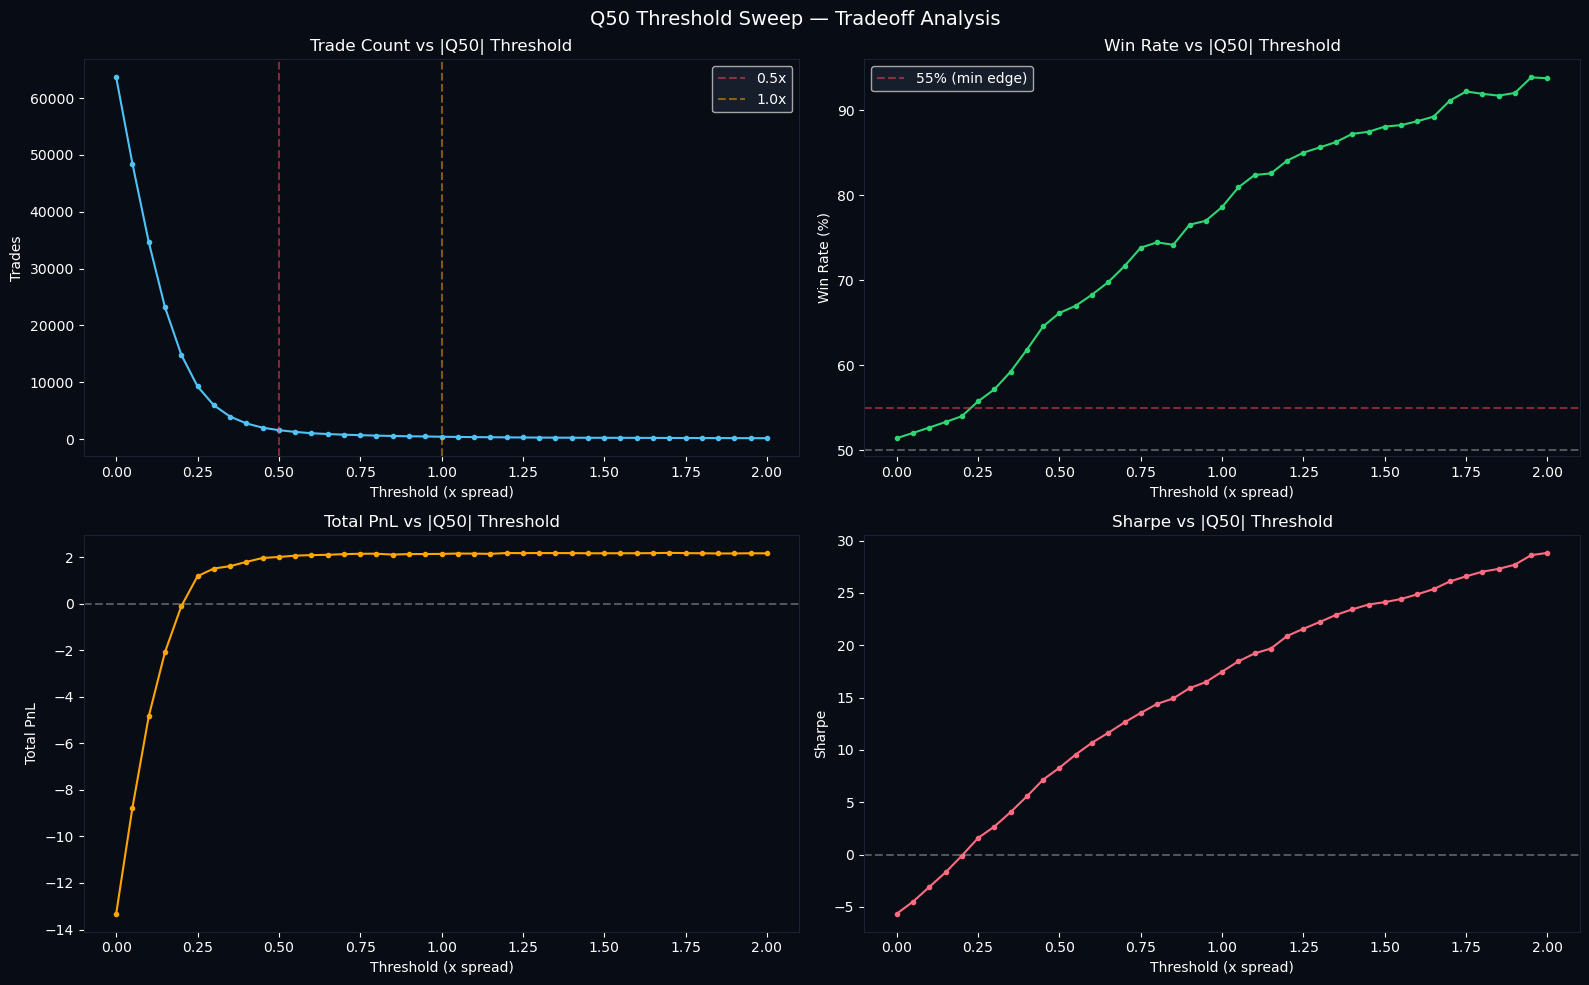

In [3]:
# Visualize the tradeoff
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#080c14')

for ax in axes.flatten():
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Trades vs threshold
axes[0,0].plot(sweep_df['threshold'], sweep_df['trades'], 'o-', color='#4fc3f7', markersize=3)
axes[0,0].set_title('Trade Count vs |Q50| Threshold', color='white')
axes[0,0].set_xlabel('Threshold (x spread)', color='white')
axes[0,0].set_ylabel('Trades', color='white')
axes[0,0].axvline(0.5, color='#ff4757', linestyle='--', alpha=0.5, label='0.5x')
axes[0,0].axvline(1.0, color='#ffa502', linestyle='--', alpha=0.5, label='1.0x')
axes[0,0].legend(facecolor='#1a2332', labelcolor='white')

# WR vs threshold
axes[0,1].plot(sweep_df['threshold'], sweep_df['wr'] * 100, 'o-', color='#2ed573', markersize=3)
axes[0,1].axhline(55, color='#ff4757', linestyle='--', alpha=0.5, label='55% (min edge)')
axes[0,1].axhline(50, color='white', linestyle='--', alpha=0.3)
axes[0,1].set_title('Win Rate vs |Q50| Threshold', color='white')
axes[0,1].set_xlabel('Threshold (x spread)', color='white')
axes[0,1].set_ylabel('Win Rate (%)', color='white')
axes[0,1].legend(facecolor='#1a2332', labelcolor='white')

# Total PnL vs threshold
axes[1,0].plot(sweep_df['threshold'], sweep_df['total_pnl'], 'o-', color='#ffa502', markersize=3)
axes[1,0].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[1,0].set_title('Total PnL vs |Q50| Threshold', color='white')
axes[1,0].set_xlabel('Threshold (x spread)', color='white')
axes[1,0].set_ylabel('Total PnL', color='white')

# Sharpe vs threshold
axes[1,1].plot(sweep_df['threshold'], sweep_df['sharpe'], 'o-', color='#ff6b81', markersize=3)
axes[1,1].axhline(0, color='white', linestyle='--', alpha=0.3)
axes[1,1].set_title('Sharpe vs |Q50| Threshold', color='white')
axes[1,1].set_xlabel('Threshold (x spread)', color='white')
axes[1,1].set_ylabel('Sharpe', color='white')

plt.suptitle('Q50 Threshold Sweep — Tradeoff Analysis', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Q25/Q75 Sign Agreement Filter

Instead of filtering on Q50 magnitude, use the quantile structure:
- **3/3 agree**: Q25, Q50, Q75 all have same sign → very confident
- **2/3 agree**: Q50 + one of Q25/Q75 agree → moderate confidence
- Trade direction = Q50 sign, but only when quantiles support it

This could unlock trades where Q50 is small but the whole distribution leans one way.

In [4]:
# Distribution of agreement levels
print('Quantile agreement distribution:')
for n in [1, 2, 3]:
    count = (results['n_agree'] == n).sum()
    pct = count / len(results) * 100
    print(f'  {n}/3 agree: {count:>8,} ({pct:.1f}%)')

print(f'\nResults by agreement level:')
print(f'{"Agreement":<12} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 70)

for n in [3, 2, 1]:
    mask = results['n_agree'] >= n
    r = evaluate(mask)
    flag = ' <<<' if r['ev'] > 0 else ''
    print(f'>={n}/3 agree {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}{flag}')

# Exact 3/3 only
mask_3 = results['n_agree'] == 3
r = evaluate(mask_3)
print(f'\nExact 3/3:   {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}')

# 3/3 agree AND |Q50| > 0 (any non-zero prediction)
mask_3_any = (results['n_agree'] == 3) & (results['abs_Q50'] > 0)
r = evaluate(mask_3_any)
print(f'3/3 & Q50≠0: {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}')

Quantile agreement distribution:
  1/3 agree:        1 (0.0%)
  2/3 agree:   63,345 (99.5%)
  3/3 agree:      291 (0.5%)

Results by agreement level:
Agreement      Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
----------------------------------------------------------------------
>=3/3 agree      291     0.53   87.6%     0.006155     1.7911    19.59 <<<
>=2/3 agree    63636   116.12   51.4%    -0.000209   -13.3198    -5.65
>=1/3 agree    63637   116.13   51.4%    -0.000209   -13.3202    -5.65

Exact 3/3:        291     0.53   87.6%     0.006155     1.7911    19.59
3/3 & Q50≠0:      291     0.53   87.6%     0.006155     1.7911    19.59


In [5]:
# Combine agreement with low Q50 threshold — can we get MORE trades with agreement?
print('3/3 agree + Q50 threshold combos:')
print(f'{"Filter":<35} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 95)

combos = [
    ('3/3 agree only', (results['n_agree'] == 3)),
    ('3/3 agree + |Q50|>0.1x', (results['n_agree'] == 3) & (results['abs_Q50'] > AVG_SPREAD * 0.1)),
    ('3/3 agree + |Q50|>0.25x', (results['n_agree'] == 3) & (results['abs_Q50'] > AVG_SPREAD * 0.25)),
    ('3/3 agree + |Q50|>0.5x', (results['n_agree'] == 3) & (results['abs_Q50'] > AVG_SPREAD * 0.5)),
    ('2/3 agree + |Q50|>0.25x', (results['n_agree'] >= 2) & (results['abs_Q50'] > AVG_SPREAD * 0.25)),
    ('2/3 agree + |Q50|>0.5x', (results['n_agree'] >= 2) & (results['abs_Q50'] > AVG_SPREAD * 0.5)),
    ('|Q50|>0.5x (baseline)', results['abs_Q50'] > AVG_SPREAD * 0.5),
    ('|Q50|>1x (baseline)', results['abs_Q50'] > AVG_SPREAD),
]

for name, mask in combos:
    r = evaluate(mask)
    flag = ' <<<' if r['ev'] > 0 else ''
    print(f'{name:<35} {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}{flag}')

3/3 agree + Q50 threshold combos:
Filter                                Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
-----------------------------------------------------------------------------------------------
3/3 agree only                           291     0.53   87.6%     0.006155     1.7911    19.59 <<<
3/3 agree + |Q50|>0.1x                   291     0.53   87.6%     0.006155     1.7911    19.59 <<<
3/3 agree + |Q50|>0.25x                  288     0.53   87.8%     0.006221     1.7915    19.71 <<<
3/3 agree + |Q50|>0.5x                   267     0.49   89.1%     0.006723     1.7951    20.56 <<<
2/3 agree + |Q50|>0.25x                 9282    16.94   55.7%     0.000127     1.1822     1.58 <<<
2/3 agree + |Q50|>0.5x                  1586     2.89   66.1%     0.001266     2.0074     8.29 <<<
|Q50|>0.5x (baseline)                   1586     2.89   66.1%     0.001266     2.0074     8.29 <<<
|Q50|>1x (baseline)                      430     0.78   78.6%     0.004979     2.

## 3. Confidence Ratio: |Q50| / IQR

When IQR is small, the model is confident about the range. If Q50 is nonzero and IQR is tight, the model "knows" the direction even if the predicted magnitude is small. This ratio could surface confident-but-small predictions.

In [6]:
# Sweep confidence ratio thresholds
print('Confidence ratio (|Q50|/IQR) sweep:')
print(f'{"Threshold":<15} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 75)

cr_thresholds = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50, 0.60, 0.75, 1.0]
cr_results = []

for cr in cr_thresholds:
    mask = results['conf_ratio'] > cr
    r = evaluate(mask)
    r['cr_threshold'] = cr
    cr_results.append(r)
    flag = ' <<<' if r['ev'] > 0 else ''
    print(f'CR > {cr:<10.2f} {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}{flag}')

cr_df = pd.DataFrame(cr_results)

Confidence ratio (|Q50|/IQR) sweep:
Threshold         Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
---------------------------------------------------------------------------
CR > 0.00          63637   116.13   51.4%    -0.000209   -13.3202    -5.65
CR > 0.05          18076    32.99   54.1%    -0.000045    -0.8195    -0.77
CR > 0.10           4047     7.39   61.7%     0.000455     1.8398     4.62 <<<
CR > 0.15           1489     2.72   69.0%     0.001422     2.1171     9.14 <<<
CR > 0.20            888     1.62   74.1%     0.002424     2.1525    12.12 <<<
CR > 0.25            653     1.19   77.5%     0.003324     2.1703    14.33 <<<
CR > 0.30            508     0.93   79.9%     0.003890     1.9759    15.54 <<<
CR > 0.35            406     0.74   82.8%     0.004402     1.7873    16.54 <<<
CR > 0.40            341     0.62   84.8%     0.003348     1.1416    18.44 <<<
CR > 0.50            252     0.46   87.7%     0.001741     0.4386    17.70 <<<
CR > 0.60            193     0

In [7]:
# Combine confidence ratio with agreement
print('Confidence ratio + agreement combos:')
print(f'{"Filter":<40} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 100)

combos2 = [
    ('CR>0.10 + 3/3 agree', (results['conf_ratio'] > 0.10) & (results['n_agree'] == 3)),
    ('CR>0.15 + 3/3 agree', (results['conf_ratio'] > 0.15) & (results['n_agree'] == 3)),
    ('CR>0.20 + 3/3 agree', (results['conf_ratio'] > 0.20) & (results['n_agree'] == 3)),
    ('CR>0.10 + 2/3 agree', (results['conf_ratio'] > 0.10) & (results['n_agree'] >= 2)),
    ('CR>0.15 + 2/3 agree', (results['conf_ratio'] > 0.15) & (results['n_agree'] >= 2)),
    ('CR>0.20 + 2/3 agree', (results['conf_ratio'] > 0.20) & (results['n_agree'] >= 2)),
    ('--- baselines ---', None),
    ('|Q50|>0.5x spread', results['abs_Q50'] > AVG_SPREAD * 0.5),
    ('|Q50|>1x spread', results['abs_Q50'] > AVG_SPREAD),
]

for name, mask in combos2:
    if mask is None:
        print(f'{name}')
        continue
    r = evaluate(mask)
    flag = ' <<<' if r['ev'] > 0 else ''
    print(f'{name:<40} {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}{flag}')

Confidence ratio + agreement combos:
Filter                                     Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
----------------------------------------------------------------------------------------------------
CR>0.10 + 3/3 agree                           291     0.53   87.6%     0.006155     1.7911    19.59 <<<
CR>0.15 + 3/3 agree                           289     0.53   87.9%     0.006201     1.7921    19.68 <<<
CR>0.20 + 3/3 agree                           287     0.52   88.2%     0.006246     1.7927    19.76 <<<
CR>0.10 + 2/3 agree                          4046     7.38   61.7%     0.000455     1.8402     4.62 <<<
CR>0.15 + 2/3 agree                          1489     2.72   69.0%     0.001422     2.1171     9.14 <<<
CR>0.20 + 2/3 agree                           888     1.62   74.1%     0.002424     2.1525    12.12 <<<
--- baselines ---
|Q50|>0.5x spread                            1586     2.89   66.1%     0.001266     2.0074     8.29 <<<
|Q50|>1x spread

## 4. Per-Pair Adaptive Thresholds

Some pairs may need much lower thresholds. Find the optimal threshold per pair independently.

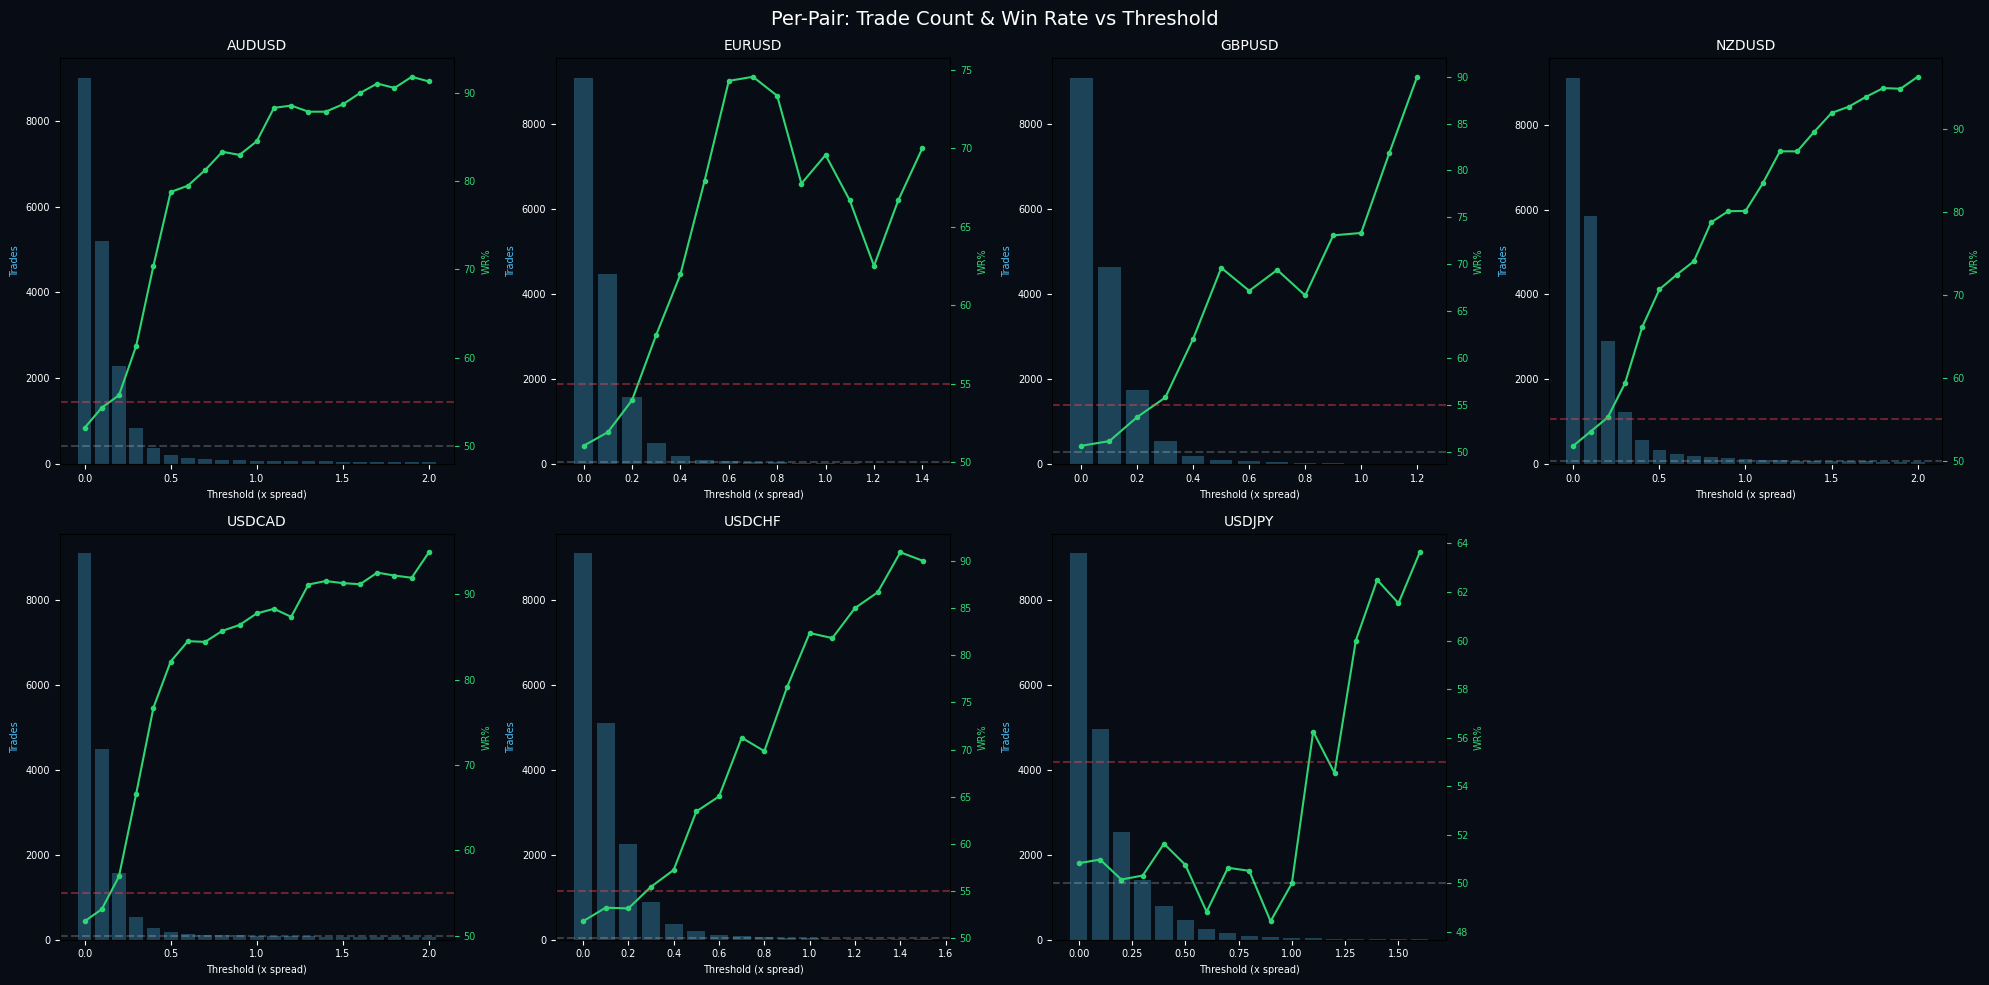

In [8]:
pairs = sorted(results['pair'].unique())
multipliers_fine = np.arange(0, 2.05, 0.1)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor('#080c14')

for idx, pair in enumerate(pairs):
    ax = axes.flatten()[idx]
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white', labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    
    pair_data = results[results['pair'] == pair]
    
    wrs, evs, trades, mults = [], [], [], []
    for m in multipliers_fine:
        thresh = AVG_SPREAD * m
        mask = pair_data['abs_Q50'] > thresh
        n = mask.sum()
        if n < 10:
            continue
        s = pair_data[mask]
        pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
        wr = (s['pred_dir'] == s['actual_dir']).mean()
        wrs.append(wr)
        evs.append(pnl.mean())
        trades.append(n)
        mults.append(m)
    
    ax2 = ax.twinx()
    ax.bar(mults, trades, width=0.08, color='#4fc3f7', alpha=0.3, label='Trades')
    ax2.plot(mults, [w*100 for w in wrs], 'o-', color='#2ed573', markersize=3, label='WR%')
    ax2.axhline(55, color='#ff4757', linestyle='--', alpha=0.4)
    ax2.axhline(50, color='white', linestyle='--', alpha=0.2)
    
    ax.set_title(f'{pair}', color='white', fontsize=10)
    ax.set_xlabel('Threshold (x spread)', color='white', fontsize=7)
    ax.set_ylabel('Trades', color='#4fc3f7', fontsize=7)
    ax2.set_ylabel('WR%', color='#2ed573', fontsize=7)
    ax2.tick_params(colors='#2ed573', labelsize=7)

# Hide unused subplot
if len(pairs) < 8:
    axes.flatten()[-1].set_visible(False)

plt.suptitle('Per-Pair: Trade Count & Win Rate vs Threshold', color='white', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
# Find best threshold per pair (maximize total PnL with WR > 55%)
print('Optimal per-pair thresholds (WR > 55%, maximize total PnL):')
print(f'\n{"Pair":<10} {"BestMult":>10} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10}')
print('-' * 70)

pair_best = {}
for pair in pairs:
    pair_data = results[results['pair'] == pair]
    best_pnl, best_config = -999, None
    
    for m in np.arange(0, 2.05, 0.05):
        thresh = AVG_SPREAD * m
        mask = pair_data['abs_Q50'] > thresh
        n = mask.sum()
        if n < 10:
            continue
        s = pair_data[mask]
        pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
        wr = (s['pred_dir'] == s['actual_dir']).mean()
        if wr >= 0.55 and pnl.sum() > best_pnl:
            best_pnl = pnl.sum()
            best_config = {'mult': m, 'trades': n, 'wr': wr, 'ev': pnl.mean(), 'total_pnl': pnl.sum(), 'daily_trades': n / n_days}
    
    if best_config:
        pair_best[pair] = best_config
        c = best_config
        print(f'{pair:<10} {c["mult"]:>9.2f}x {c["trades"]:>8} {c["daily_trades"]:>8.2f} {c["wr"]:>7.1%} {c["ev"]:>12.6f} {c["total_pnl"]:>10.4f}')
    else:
        print(f'{pair:<10} {"NO EDGE":>10}')

# Simulate combined adaptive strategy
print(f'\n--- Adaptive Strategy (per-pair optimal thresholds) ---')
adaptive_mask = pd.Series(False, index=results.index)
for pair, cfg in pair_best.items():
    thresh = AVG_SPREAD * cfg['mult']
    pair_mask = (results['pair'] == pair) & (results['abs_Q50'] > thresh)
    adaptive_mask |= pair_mask

r = evaluate(adaptive_mask)
print(f'Trades: {r["trades"]:.0f} ({r["daily_trades"]:.2f}/day)')
print(f'WR: {r["wr"]:.1%}, EV: {r["ev"]:.6f}, Total PnL: {r["total_pnl"]:.4f}, Sharpe: {r["sharpe"]:.2f}')

Optimal per-pair thresholds (WR > 55%, maximize total PnL):

Pair         BestMult   Trades   Tr/day       WR     EV/trade   TotalPnL
----------------------------------------------------------------------
AUDUSD          0.45x      275     0.50   78.2%     0.001006     0.2768
EURUSD          1.00x       23     0.04   69.6%     0.001707     0.0393
GBPUSD          1.05x       12     0.02   83.3%     0.000030     0.0004
NZDUSD          0.25x     1883     3.44   57.6%     0.000528     0.9943
USDCAD          0.30x      531     0.97   66.7%     0.002613     1.3877
USDCHF          0.70x       87     0.16   71.3%     0.000251     0.0218
USDJPY          1.40x       16     0.03   62.5%    -0.000096    -0.0015

--- Adaptive Strategy (per-pair optimal thresholds) ---
Trades: 2827 (5.16/day)
WR: 61.9%, EV: 0.000962, Total PnL: 2.7186, Sharpe: 6.75


## 5. Q50 Recalibration — Is the Model Under-Predicting?

Check if actual moves are systematically larger than Q50 predictions. If so, the model is too conservative in magnitude (even if direction is right), and we could scale up Q50 to get more trades past the threshold.

In [10]:
# Compare predicted vs actual magnitudes
correct_dir = results['pred_dir'] == results['actual_dir']

print('Q50 vs Actual magnitude comparison:')
print(f'  Mean |Q50|:          {results["abs_Q50"].mean():.6f}')
print(f'  Mean |actual|:       {results["abs_return"].mean():.6f}')
print(f'  Ratio actual/Q50:    {results["abs_return"].mean() / results["abs_Q50"].mean():.2f}x')
print(f'  Median |Q50|:        {results["abs_Q50"].median():.6f}')
print(f'  Median |actual|:     {results["abs_return"].median():.6f}')
print(f'  Ratio actual/Q50:    {results["abs_return"].median() / results["abs_Q50"].median():.2f}x')

# When model is correct on direction, how much bigger is actual move?
correct = results[correct_dir]
print(f'\nWhen direction is CORRECT ({len(correct):,} rows):')
print(f'  Mean |Q50|:          {correct["abs_Q50"].mean():.6f}')
print(f'  Mean |actual|:       {correct["abs_return"].mean():.6f}')
print(f'  Ratio:               {correct["abs_return"].mean() / correct["abs_Q50"].mean():.2f}x')

# Bin by |Q50| and see actual/predicted ratio
print(f'\nActual vs Predicted by Q50 magnitude bin:')
print(f'{"Q50 bin":<25} {"Count":>8} {"Mean|Q50|":>12} {"Mean|Act|":>12} {"Ratio":>8} {"WR":>8}')
print('-' * 80)

bins = [0, 0.00005, 0.0001, 0.00014, 0.00020, 0.00028, 0.0005, 0.001, 0.01]
labels = [f'{bins[i]:.5f}-{bins[i+1]:.5f}' for i in range(len(bins)-1)]
results['q50_bin'] = pd.cut(results['abs_Q50'], bins=bins, labels=labels, include_lowest=True)

for label in labels:
    b = results[results['q50_bin'] == label]
    if len(b) < 10:
        continue
    ratio = b['abs_return'].mean() / b['abs_Q50'].mean() if b['abs_Q50'].mean() > 0 else np.nan
    wr = (b['pred_dir'] == b['actual_dir']).mean()
    print(f'{label:<25} {len(b):>8,} {b["abs_Q50"].mean():>12.6f} {b["abs_return"].mean():>12.6f} {ratio:>7.1f}x {wr:>7.1%}')

Q50 vs Actual magnitude comparison:
  Mean |Q50|:          0.000047
  Mean |actual|:       0.000785
  Ratio actual/Q50:    16.60x
  Median |Q50|:        0.000031
  Median |actual|:     0.000479
  Ratio actual/Q50:    15.36x

When direction is CORRECT (32,714 rows):
  Mean |Q50|:          0.000055
  Mean |actual|:       0.000833
  Ratio:               15.07x

Actual vs Predicted by Q50 magnitude bin:
Q50 bin                      Count    Mean|Q50|    Mean|Act|    Ratio       WR
--------------------------------------------------------------------------------
0.00000-0.00005             45,582     0.000023     0.000698    31.0x   50.4%
0.00005-0.00010             14,248     0.000068     0.000844    12.4x   52.3%
0.00010-0.00014              2,221     0.000115     0.000981     8.5x   55.0%
0.00014-0.00020                830     0.000163     0.001146     7.0x   60.5%
0.00020-0.00028                326     0.000235     0.001292     5.5x   64.1%
0.00028-0.00050                229     0.000355

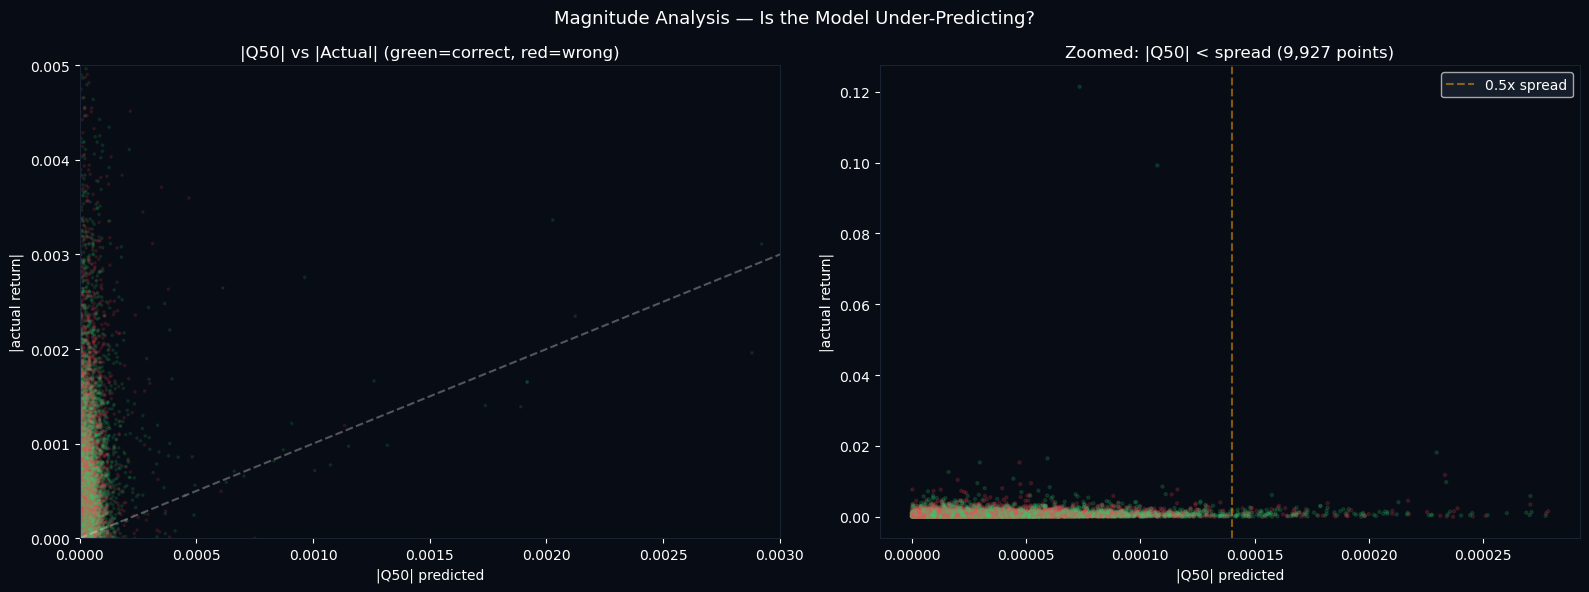

In [11]:
# Scatter: |Q50| vs |actual| with color by correct/wrong
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Left: full range
sample = results.sample(min(10000, len(results)), random_state=42)
colors = np.where(sample['pred_dir'] == sample['actual_dir'], '#2ed573', '#ff4757')
axes[0].scatter(sample['abs_Q50'], sample['abs_return'], c=colors, alpha=0.1, s=3)
axes[0].plot([0, 0.005], [0, 0.005], '--', color='white', alpha=0.3)
axes[0].set_xlabel('|Q50| predicted', color='white')
axes[0].set_ylabel('|actual return|', color='white')
axes[0].set_title('|Q50| vs |Actual| (green=correct, red=wrong)', color='white')
axes[0].set_xlim(0, 0.003)
axes[0].set_ylim(0, 0.005)

# Right: zoom into the low-Q50 region where most predictions live
low = sample[sample['abs_Q50'] < AVG_SPREAD]
colors_low = np.where(low['pred_dir'] == low['actual_dir'], '#2ed573', '#ff4757')
axes[1].scatter(low['abs_Q50'], low['abs_return'], c=colors_low, alpha=0.15, s=5)
axes[1].axvline(AVG_SPREAD * 0.5, color='#ffa502', linestyle='--', alpha=0.5, label='0.5x spread')
axes[1].set_xlabel('|Q50| predicted', color='white')
axes[1].set_ylabel('|actual return|', color='white')
axes[1].set_title(f'Zoomed: |Q50| < spread ({len(low):,} points)', color='white')
axes[1].legend(facecolor='#1a2332', labelcolor='white')

plt.suptitle('Magnitude Analysis — Is the Model Under-Predicting?', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Alternative Direction Signal — Q25/Q75 Boundary

Instead of using Q50 sign for direction, what if we use:
- **Q25 > 0** → the model thinks even the 25th percentile outcome is positive → strong long signal
- **Q75 < 0** → even the 75th percentile is negative → strong short signal

This is a stricter directional signal but doesn't depend on Q50 magnitude at all.

In [12]:
# Q25 > 0 (long) or Q75 < 0 (short) — the entire IQR is on one side
long_signal  = results['Q25'] > 0  # even pessimistic case is positive
short_signal = results['Q75'] < 0  # even optimistic case is negative
boundary_mask = long_signal | short_signal
boundary_dir = np.where(long_signal, 1, np.where(short_signal, -1, 0))

print('Q25/Q75 Boundary Signal:')
print(f'  Long signals (Q25>0):   {long_signal.sum():>8,}')
print(f'  Short signals (Q75<0):  {short_signal.sum():>8,}')
print(f'  Total:                  {boundary_mask.sum():>8,} ({boundary_mask.sum()/n_days:.2f}/day)')

# Evaluate
s = results[boundary_mask]
d = pd.Series(boundary_dir[boundary_mask], index=s.index)
pnl = d * s['actual_return'] - AVG_SPREAD
wr = (d == s['actual_dir']).mean()
sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0

print(f'\n  WR: {wr:.1%}')
print(f'  EV/trade: {pnl.mean():.6f}')
print(f'  Total PnL: {pnl.sum():.4f}')
print(f'  Sharpe: {sharpe:.2f}')

# Also try: Q25 > -spread (long) or Q75 < spread (short) — relaxed version
print(f'\n--- Relaxed: Q25 > -spread (long) or Q75 < spread (short) ---')
long_relax  = results['Q25'] > -AVG_SPREAD
short_relax = results['Q75'] < AVG_SPREAD
# Only where Q50 gives a direction
relax_long_mask = long_relax & (results['pred_dir'] == 1)
relax_short_mask = short_relax & (results['pred_dir'] == -1)
relax_mask = relax_long_mask | relax_short_mask

r = evaluate(relax_mask)
print(f'  Trades: {r["trades"]:.0f} ({r["daily_trades"]:.2f}/day)')
print(f'  WR: {r["wr"]:.1%}, EV: {r["ev"]:.6f}, Total PnL: {r["total_pnl"]:.4f}, Sharpe: {r["sharpe"]:.2f}')

Q25/Q75 Boundary Signal:
  Long signals (Q25>0):        292
  Short signals (Q75<0):         0
  Total:                       292 (0.53/day)

  WR: 87.7%
  EV/trade: 0.006133
  Total PnL: 1.7910
  Sharpe: 19.56

--- Relaxed: Q25 > -spread (long) or Q75 < spread (short) ---
  Trades: 10446 (19.06/day)
  WR: 54.5%, EV: -0.000016, Total PnL: -0.1642, Sharpe: -0.27


## 7. Grand Comparison — All Strategies Side by Side

Compare every filter we tested. Equity curves for the top contenders.

In [13]:
# Grand comparison table
print(f'{"Strategy":<40} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV/trade":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('=' * 100)

strategies_final = {
    # Q50 thresholds
    '|Q50| > 0x (all)':          results['abs_Q50'] > 0,
    '|Q50| > 0.1x spread':      results['abs_Q50'] > AVG_SPREAD * 0.1,
    '|Q50| > 0.25x spread':     results['abs_Q50'] > AVG_SPREAD * 0.25,
    '|Q50| > 0.5x spread':      results['abs_Q50'] > AVG_SPREAD * 0.5,
    '|Q50| > 1x spread':        results['abs_Q50'] > AVG_SPREAD,
    # Agreement
    '3/3 agree':                 results['n_agree'] == 3,
    '3/3 agree + |Q50|>0.1x':   (results['n_agree'] == 3) & (results['abs_Q50'] > AVG_SPREAD * 0.1),
    '3/3 agree + |Q50|>0.25x':  (results['n_agree'] == 3) & (results['abs_Q50'] > AVG_SPREAD * 0.25),
    # Confidence ratio
    'CR > 0.15':                 results['conf_ratio'] > 0.15,
    'CR > 0.20':                 results['conf_ratio'] > 0.20,
    'CR > 0.25':                 results['conf_ratio'] > 0.25,
    # Boundary
    'Q25>0 or Q75<0':           boundary_mask,
    # Adaptive
    'Per-pair adaptive':         adaptive_mask,
}

strategy_results = {}
for name, mask in strategies_final.items():
    r = evaluate(mask)
    strategy_results[name] = r
    flag = ' <<<' if r['ev'] > 0 else ''
    print(f'{name:<40} {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}{flag}')

Strategy                                   Trades   Tr/day       WR     EV/trade   TotalPnL   Sharpe
|Q50| > 0x (all)                            63637   116.13   51.4%    -0.000209   -13.3202    -5.65
|Q50| > 0.1x spread                         34694    63.31   52.7%    -0.000140    -4.8458    -3.10
|Q50| > 0.25x spread                         9282    16.94   55.7%     0.000127     1.1822     1.58 <<<
|Q50| > 0.5x spread                          1586     2.89   66.1%     0.001266     2.0074     8.29 <<<
|Q50| > 1x spread                             430     0.78   78.6%     0.004979     2.1408    17.48 <<<
3/3 agree                                     291     0.53   87.6%     0.006155     1.7911    19.59 <<<
3/3 agree + |Q50|>0.1x                        291     0.53   87.6%     0.006155     1.7911    19.59 <<<
3/3 agree + |Q50|>0.25x                       288     0.53   87.8%     0.006221     1.7915    19.71 <<<
CR > 0.15                                    1489     2.72   69.0%     0.00

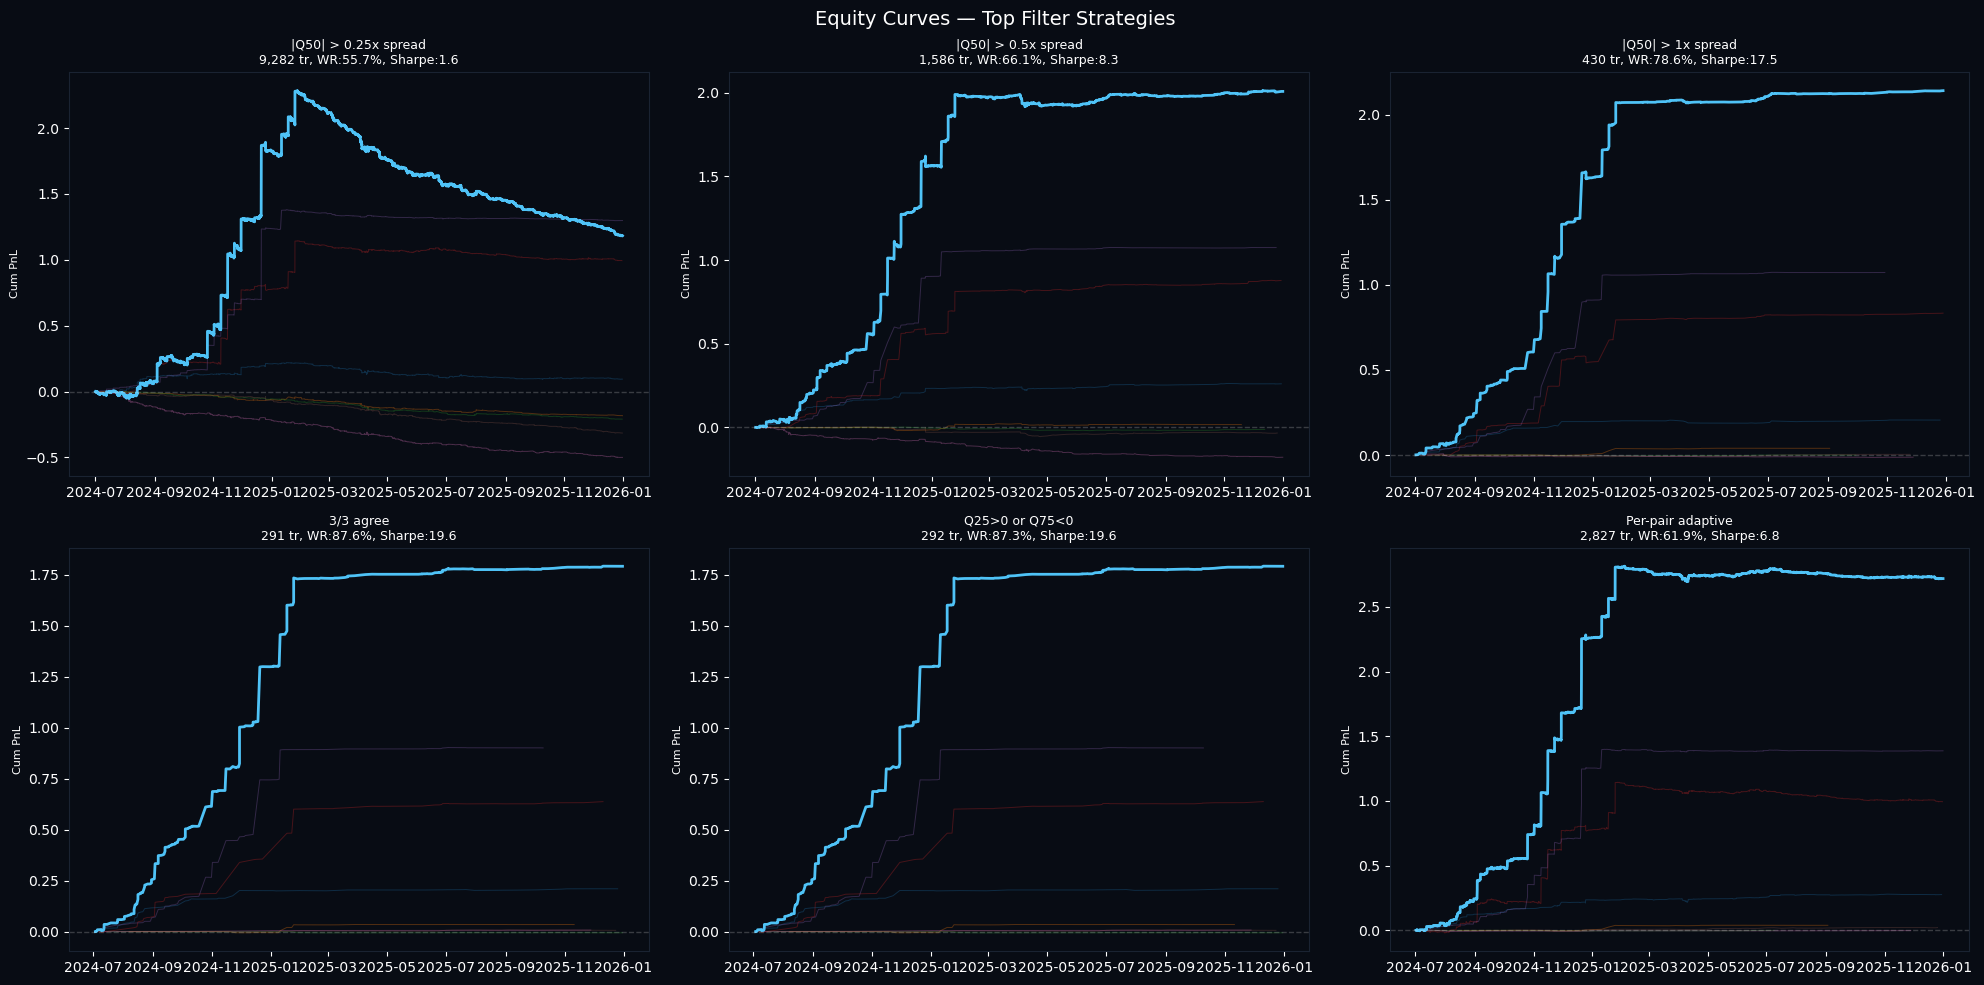

In [14]:
# Equity curves for top strategies
top_strategies = {
    '|Q50| > 0.25x spread':     results['abs_Q50'] > AVG_SPREAD * 0.25,
    '|Q50| > 0.5x spread':      results['abs_Q50'] > AVG_SPREAD * 0.5,
    '|Q50| > 1x spread':        results['abs_Q50'] > AVG_SPREAD,
    '3/3 agree':                 results['n_agree'] == 3,
    'Q25>0 or Q75<0':           boundary_mask,
    'Per-pair adaptive':         adaptive_mask,
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.patch.set_facecolor('#080c14')

for ax, (name, mask) in zip(axes.flatten(), top_strategies.items()):
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
    
    s = results[mask]
    pnl = s['pred_dir'] * s['actual_return'] - AVG_SPREAD
    cum_pnl = pnl.cumsum()
    
    # Per-pair curves
    for pair in sorted(s['pair'].unique()):
        p = s[s['pair'] == pair]
        pair_pnl = (p['pred_dir'] * p['actual_return'] - AVG_SPREAD).cumsum()
        ax.plot(pair_pnl.index, pair_pnl.values, alpha=0.3, linewidth=0.7)
    
    ax.plot(cum_pnl.index, cum_pnl.values, color='#4fc3f7', linewidth=2)
    ax.axhline(0, color=(1,1,1,0.2), linewidth=1, linestyle='--')
    
    wr = (s['pred_dir'] == s['actual_dir']).mean()
    ev = pnl.mean()
    sharpe = (pnl.mean() / pnl.std()) * np.sqrt(252 * 24) if pnl.std() > 0 else 0
    
    ax.set_title(f'{name}\n{mask.sum():,} tr, WR:{wr:.1%}, Sharpe:{sharpe:.1f}', color='white', fontsize=9)
    ax.set_ylabel('Cum PnL', color='white', fontsize=8)

plt.suptitle('Equity Curves — Top Filter Strategies', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Efficiency Frontier — Trades vs Total PnL vs WR

Plot all strategies on a single chart to see the tradeoff frontier.

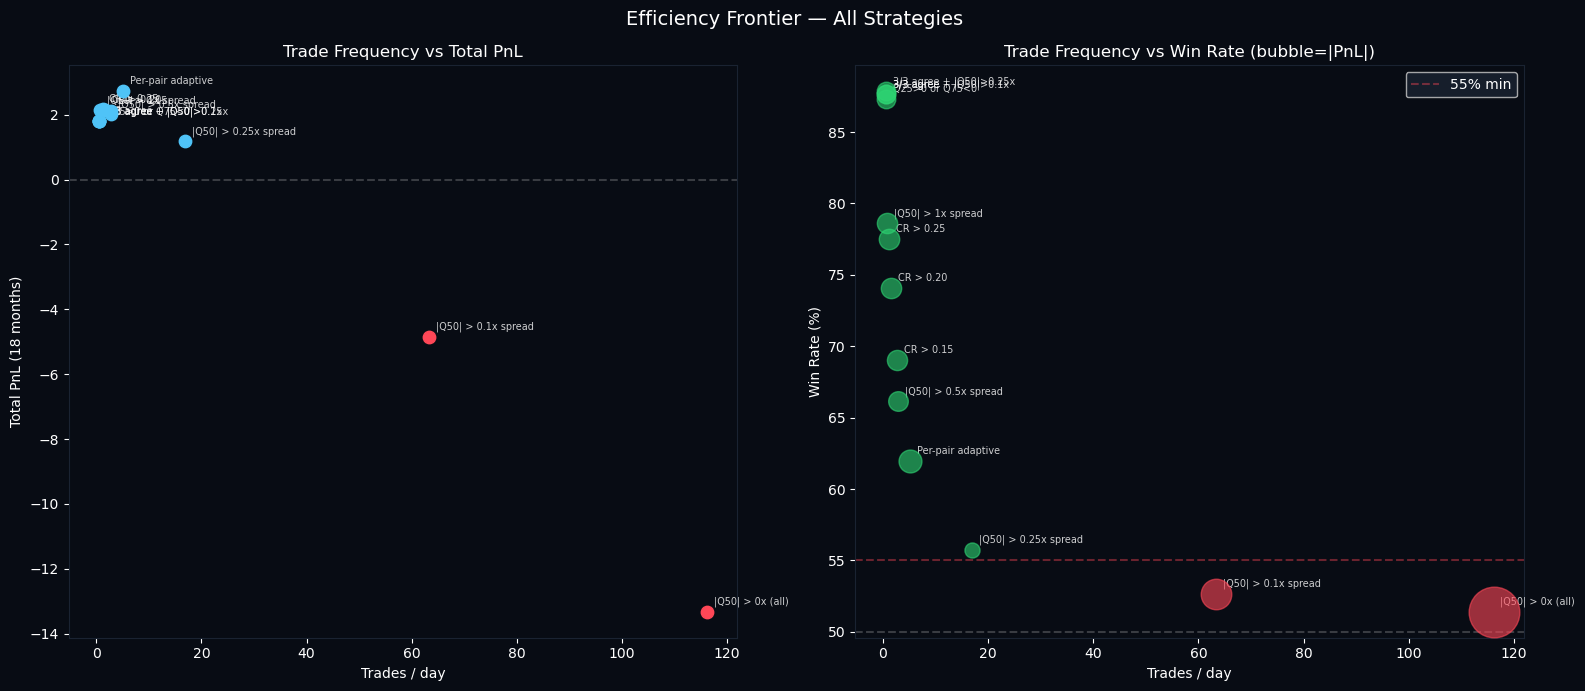

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#080c14')

for ax in axes:
    ax.set_facecolor('#080c14')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

# Left: Trades/day vs Total PnL
for name, r in strategy_results.items():
    if r['trades'] < 10 or np.isnan(r['total_pnl']):
        continue
    color = '#4fc3f7' if r['total_pnl'] > 0 else '#ff4757'
    axes[0].scatter(r['daily_trades'], r['total_pnl'], color=color, s=80, zorder=5)
    axes[0].annotate(name, (r['daily_trades'], r['total_pnl']),
                     textcoords='offset points', xytext=(5, 5),
                     color='white', fontsize=7, alpha=0.8)

axes[0].axhline(0, color='white', linestyle='--', alpha=0.2)
axes[0].set_xlabel('Trades / day', color='white')
axes[0].set_ylabel('Total PnL (18 months)', color='white')
axes[0].set_title('Trade Frequency vs Total PnL', color='white')

# Right: Trades/day vs Win Rate (bubble size = total PnL)
for name, r in strategy_results.items():
    if r['trades'] < 10 or np.isnan(r['wr']):
        continue
    size = max(20, abs(r['total_pnl']) * 100)
    color = '#2ed573' if r['total_pnl'] > 0 else '#ff4757'
    axes[1].scatter(r['daily_trades'], r['wr'] * 100, color=color, s=size, alpha=0.6, zorder=5)
    axes[1].annotate(name, (r['daily_trades'], r['wr'] * 100),
                     textcoords='offset points', xytext=(5, 5),
                     color='white', fontsize=7, alpha=0.8)

axes[1].axhline(55, color='#ff4757', linestyle='--', alpha=0.4, label='55% min')
axes[1].axhline(50, color='white', linestyle='--', alpha=0.2)
axes[1].set_xlabel('Trades / day', color='white')
axes[1].set_ylabel('Win Rate (%)', color='white')
axes[1].set_title('Trade Frequency vs Win Rate (bubble=|PnL|)', color='white')
axes[1].legend(facecolor='#1a2332', labelcolor='white')

plt.suptitle('Efficiency Frontier — All Strategies', color='white', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Summary & Recommendations

In [16]:
# Rank strategies by total PnL (only profitable ones)
print('=' * 100)
print('STRATEGY RANKING — by Total PnL (profitable only, WR > 55%)')
print('=' * 100)

ranked = [(name, r) for name, r in strategy_results.items() 
          if r['total_pnl'] > 0 and r['wr'] > 0.55 and r['trades'] >= 20]
ranked.sort(key=lambda x: x[1]['total_pnl'], reverse=True)

print(f'\n{"Rank":<5} {"Strategy":<40} {"Trades":>8} {"Tr/day":>8} {"WR":>8} {"EV":>12} {"TotalPnL":>10} {"Sharpe":>8}')
print('-' * 105)

for i, (name, r) in enumerate(ranked, 1):
    print(f'{i:<5} {name:<40} {r["trades"]:>8.0f} {r["daily_trades"]:>8.2f} {r["wr"]:>7.1%} {r["ev"]:>12.6f} {r["total_pnl"]:>10.4f} {r["sharpe"]:>8.2f}')

print(f'\n--- Key Findings ---')
print(f'1. Best total PnL comes from: {ranked[0][0]} ({ranked[0][1]["total_pnl"]:.4f})')
most_trades = max(ranked, key=lambda x: x[1]['trades'])
print(f'2. Most trades with edge: {most_trades[0]} ({most_trades[1]["trades"]:.0f} trades, {most_trades[1]["daily_trades"]:.2f}/day)')
best_wr = max(ranked, key=lambda x: x[1]['wr'])
print(f'3. Highest WR: {best_wr[0]} ({best_wr[1]["wr"]:.1%})')
best_sharpe = max(ranked, key=lambda x: x[1]['sharpe'])
print(f'4. Best Sharpe: {best_sharpe[0]} ({best_sharpe[1]["sharpe"]:.2f})')

STRATEGY RANKING — by Total PnL (profitable only, WR > 55%)

Rank  Strategy                                   Trades   Tr/day       WR           EV   TotalPnL   Sharpe
---------------------------------------------------------------------------------------------------------
1     Per-pair adaptive                            2827     5.16   61.9%     0.000962     2.7186     6.75
2     CR > 0.25                                     653     1.19   77.5%     0.003324     2.1703    14.33
3     CR > 0.20                                     888     1.62   74.1%     0.002424     2.1525    12.12
4     |Q50| > 1x spread                             430     0.78   78.6%     0.004979     2.1408    17.48
5     CR > 0.15                                    1489     2.72   69.0%     0.001422     2.1171     9.14
6     |Q50| > 0.5x spread                          1586     2.89   66.1%     0.001266     2.0074     8.29
7     3/3 agree + |Q50|>0.25x                       288     0.53   87.8%     0.006221     